# Ablation Study — PHEME Rumor Detection

## 5 Configs: TF-IDF → MiniLM → +Propagation → +Graph(KG v2) → Full Hybrid

**Sinh viên:** Phạm Phước Tài (64132083)  
**GVHD:** TS. Phạm Thị Thu Thúy  
**Dataset:** PHEME — 5,802 threads, 102,440 tweets, 5 events

**Pipeline chính thức:** MiniLM(384) + Propagation(4) + Graph(14) = 402 features  
**Classifier:** LogisticRegression(C=1.0, max_iter=1000, random_state=42)  
**Split:** Stratified train/test theo thread_id, random_state=42, test_size=0.2  
**Graph features:** data/processed/graph_features_v2.csv (trích từ KG v2)

In [8]:
# ============================================================
# IMPORTS & GLOBAL CONFIGURATION
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Rectangle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Global matplotlib style (thesis-ready)
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'savefig.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.2,
})

print("Imports and configuration loaded successfully")

Imports and configuration loaded successfully


In [9]:
# ============================================================
# LOAD DATA
# ============================================================
# Load base features (post-level, has text and label)
base_df = pd.read_csv('../data/processed/pheme_features.csv', dtype={'reply_to': str})
print(f"Base features: {base_df.shape}")
print(f"Unique threads: {base_df['thread_id'].nunique()}")

# Load graph features v2 (thread-level)
graph_df = pd.read_csv('../data/processed/graph_features_v2.csv')
print(f"Graph features v2: {graph_df.shape}")

# Build thread-level dataframe
# For each thread: get label (from source post), thread text (concatenate all texts)
thread_data = []
for tid, group in base_df.groupby('thread_id'):
    source = group[group['depth'] == 0].iloc[0] if len(group[group['depth'] == 0]) > 0 else group.iloc[0]
    label = int(source['label'])
    
    # Thread-level text: combine source + top-level replies for MiniLM
    all_text = ' '.join(group['text'].dropna().astype(str).tolist())
    
    thread_data.append({
        'thread_id': int(tid),
        'label': label,
        'text': all_text,
        'source_text': str(source['text']),
    })

thread_df = pd.DataFrame(thread_data)
print(f"Thread data: {thread_df.shape}")
print(f"  Non-rumor: {(thread_df['label'] == 0).sum()}, Rumor: {(thread_df['label'] == 1).sum()}")

# Merge with graph features
thread_df = thread_df.merge(graph_df, on='thread_id', how='left')
print(f"After merge: {thread_df.shape}")
print(f"  Nulls after merge: {thread_df.isnull().sum().sum()}")

# Propagation features from base data (thread-level)
# Build only the propagation-specific features (avg_depth_prop, reply_rate)
avg_depth_per_thread = base_df.groupby('thread_id')['depth'].mean().reset_index()
avg_depth_per_thread.columns = ['thread_id', 'avg_depth_prop']

thread_sizes = base_df.groupby('thread_id').agg(
    thread_size=('thread_size', 'first'),
    max_depth=('max_depth', 'first'),
    reply_speed=('reply_speed_per_hour', 'first'),
).reset_index()

reply_counts = base_df.groupby('thread_id').size().reset_index()
reply_counts.columns = ['thread_id', 'total_posts']

# Merge propagation features into thread_df cleanly
thread_df = thread_df.merge(thread_sizes[['thread_id', 'thread_size', 'max_depth']], on='thread_id', how='left')
thread_df = thread_df.merge(avg_depth_per_thread, on='thread_id', how='left')
thread_df['reply_rate'] = reply_counts['total_posts'] / (thread_df['thread_size'] + 1)

# Final 4 propagation feature column names
prop_cols = ['thread_size', 'max_depth', 'avg_depth_prop', 'reply_rate']

print(f"Final thread data: {thread_df.shape}")
print(f"Columns: {list(thread_df.columns)}")

Base features: (102440, 17)
Unique threads: 5802
Graph features v2: (5802, 15)
Thread data: (5802, 4)
  Non-rumor: 3830, Rumor: 1972
After merge: (5802, 18)
  Nulls after merge: 0
Final thread data: (5802, 22)
Columns: ['thread_id', 'label', 'text', 'source_text', 'thread_depth', 'num_nodes', 'num_edges', 'avg_branching_factor', 'max_branching_factor', 'source_reply_count', 'leaf_ratio', 'avg_depth', 'source_pagerank', 'avg_pagerank', 'source_centrality', 'avg_centrality', 'user_rumor_ratio', 'unique_users', 'thread_size', 'max_depth', 'avg_depth_prop', 'reply_rate']


In [10]:
# ============================================================
# GENERATE MINILM EMBEDDINGS (thread-level)
# ============================================================
from sentence_transformers import SentenceTransformer

print("Loading MiniLM model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded. Generating embeddings...")

# Generate embeddings for thread source text
texts = thread_df['source_text'].fillna('').tolist()
embeddings = model.encode(texts, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {embeddings.shape}")

# Store as numpy file for reproducibility
np.save('../data/processed/minilm_embeddings_thread.npy', embeddings)
print("Saved to data/processed/minilm_embeddings_thread.npy")

Loading MiniLM model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded. Generating embeddings...


Batches:   0%|          | 0/91 [00:00<?, ?it/s]

Embeddings shape: (5802, 384)
Saved to data/processed/minilm_embeddings_thread.npy


In [11]:
# ============================================================
# TRAIN/TEST SPLIT (stratified by thread_id)
# ============================================================
RANDOM_STATE = 42
TEST_SIZE = 0.2

y = thread_df['label'].values

# Stratified split
train_idx, test_idx = train_test_split(
    np.arange(len(thread_df)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train size: {len(train_idx)}, Test size: {len(test_idx)}")
print(f"Train rumor ratio: {y[train_idx].mean():.3f}, Test rumor ratio: {y[test_idx].mean():.3f}")

y_train = y[train_idx]
y_test = y[test_idx]

Train size: 4641, Test size: 1161
Train rumor ratio: 0.340, Test rumor ratio: 0.340


In [12]:
# ============================================================
# CONFIG 1: TF-IDF ONLY
# ============================================================
print("=" * 60)
print("CONFIG 1: TF-IDF only")
print("=" * 60)

tfidf_vec = TfidfVectorizer(max_features=10000, stop_words='english', 
                             ngram_range=(1, 2), min_df=2, max_df=0.95)
X_tfidf = tfidf_vec.fit_transform(thread_df['text'].fillna(''))
print(f"TF-IDF matrix shape: {X_tfidf.shape}")

X1_train = X_tfidf[train_idx]
X1_test = X_tfidf[test_idx]

clf1 = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
clf1.fit(X1_train, y_train)
y1_pred = clf1.predict(X1_test)

cm1 = confusion_matrix(y_test, y1_pred)
results = {}
results['TF-IDF'] = {
    'Accuracy': accuracy_score(y_test, y1_pred),
    'Precision': precision_score(y_test, y1_pred, zero_division=0),
    'Recall': recall_score(y_test, y1_pred, zero_division=0),
    'F1': f1_score(y_test, y1_pred, zero_division=0),
    'FN': int(cm1[1][0]),
    'ConfusionMatrix': cm1.tolist(),
}
print(f"  Acc={results['TF-IDF']['Accuracy']:.4f}, Prec={results['TF-IDF']['Precision']:.4f}, "
      f"Recall={results['TF-IDF']['Recall']:.4f}, F1={results['TF-IDF']['F1']:.4f}, FN={results['TF-IDF']['FN']}")

CONFIG 1: TF-IDF only
TF-IDF matrix shape: (5802, 10000)
  Acc=0.8269, Prec=0.8368, Recall=0.6101, F1=0.7057, FN=154


In [13]:
# ============================================================
# CONFIG 2: MINILM ONLY
# ============================================================
print("=" * 60)
print("CONFIG 2: MiniLM only (384d)")
print("=" * 60)

X2 = embeddings  # (5802, 384)
X2_train = X2[train_idx]
X2_test = X2[test_idx]

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

clf2 = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
clf2.fit(X2_train_scaled, y_train)
y2_pred = clf2.predict(X2_test_scaled)

cm2 = confusion_matrix(y_test, y2_pred)
results['MiniLM'] = {
    'Accuracy': accuracy_score(y_test, y2_pred),
    'Precision': precision_score(y_test, y2_pred, zero_division=0),
    'Recall': recall_score(y_test, y2_pred, zero_division=0),
    'F1': f1_score(y_test, y2_pred, zero_division=0),
    'FN': int(cm2[1][0]),
    'ConfusionMatrix': cm2.tolist(),
}
print(f"  Acc={results['MiniLM']['Accuracy']:.4f}, Prec={results['MiniLM']['Precision']:.4f}, "
      f"Recall={results['MiniLM']['Recall']:.4f}, F1={results['MiniLM']['F1']:.4f}, FN={results['MiniLM']['FN']}")

CONFIG 2: MiniLM only (384d)
  Acc=0.8338, Prec=0.7603, Recall=0.7468, F1=0.7535, FN=100


In [14]:
# ============================================================
# CONFIG 3: MINILM + PROPAGATION
# ============================================================
print("=" * 60)
print("CONFIG 3: MiniLM + Propagation (384 + 4 = 388d)")
print("=" * 60)

# Propagation features
X_prop = thread_df[prop_cols].fillna(0).values

X3 = np.hstack([embeddings, X_prop])
print(f"Config 3 feature dim: {X3.shape[1]}")

X3_train = X3[train_idx]
X3_test = X3[test_idx]

scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

clf3 = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
clf3.fit(X3_train_scaled, y_train)
y3_pred = clf3.predict(X3_test_scaled)

cm3 = confusion_matrix(y_test, y3_pred)
results['MiniLM+Prop'] = {
    'Accuracy': accuracy_score(y_test, y3_pred),
    'Precision': precision_score(y_test, y3_pred, zero_division=0),
    'Recall': recall_score(y_test, y3_pred, zero_division=0),
    'F1': f1_score(y_test, y3_pred, zero_division=0),
    'FN': int(cm3[1][0]),
    'ConfusionMatrix': cm3.tolist(),
}
print(f"  Acc={results['MiniLM+Prop']['Accuracy']:.4f}, Prec={results['MiniLM+Prop']['Precision']:.4f}, "
      f"Recall={results['MiniLM+Prop']['Recall']:.4f}, F1={results['MiniLM+Prop']['F1']:.4f}, FN={results['MiniLM+Prop']['FN']}")

CONFIG 3: MiniLM + Propagation (384 + 4 = 388d)
Config 3 feature dim: 388
  Acc=0.8355, Prec=0.7642, Recall=0.7468, F1=0.7554, FN=100


In [15]:
# ============================================================
# CONFIG 4: MINILM + GRAPH (KG v2)
# ============================================================
print("=" * 60)
print("CONFIG 4: MiniLM + Graph(KG v2) (384 + 14 = 398d)")
print("=" * 60)

graph_cols = ['thread_depth', 'num_nodes', 'num_edges', 'avg_branching_factor',
              'max_branching_factor', 'source_reply_count', 'leaf_ratio', 'avg_depth',
              'source_pagerank', 'avg_pagerank', 'source_centrality', 'avg_centrality',
              'user_rumor_ratio', 'unique_users']

X_graph = thread_df[graph_cols].fillna(0).values
print(f"Graph features shape: {X_graph.shape}")

X4 = np.hstack([embeddings, X_graph])
print(f"Config 4 feature dim: {X4.shape[1]}")

X4_train = X4[train_idx]
X4_test = X4[test_idx]

scaler4 = StandardScaler()
X4_train_scaled = scaler4.fit_transform(X4_train)
X4_test_scaled = scaler4.transform(X4_test)

clf4 = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
clf4.fit(X4_train_scaled, y_train)
y4_pred = clf4.predict(X4_test_scaled)

cm4 = confusion_matrix(y_test, y4_pred)
results['MiniLM+Graph'] = {
    'Accuracy': accuracy_score(y_test, y4_pred),
    'Precision': precision_score(y_test, y4_pred, zero_division=0),
    'Recall': recall_score(y_test, y4_pred, zero_division=0),
    'F1': f1_score(y_test, y4_pred, zero_division=0),
    'FN': int(cm4[1][0]),
    'ConfusionMatrix': cm4.tolist(),
}
print(f"  Acc={results['MiniLM+Graph']['Accuracy']:.4f}, Prec={results['MiniLM+Graph']['Precision']:.4f}, "
      f"Recall={results['MiniLM+Graph']['Recall']:.4f}, F1={results['MiniLM+Graph']['F1']:.4f}, FN={results['MiniLM+Graph']['FN']}")

CONFIG 4: MiniLM + Graph(KG v2) (384 + 14 = 398d)
Graph features shape: (5802, 14)
Config 4 feature dim: 398
  Acc=0.9811, Prec=0.9794, Recall=0.9646, F1=0.9719, FN=14


In [16]:
# ============================================================
# CONFIG 5: FULL HYBRID (MiniLM + Propagation + Graph v2)
# ============================================================
print("=" * 60)
print("CONFIG 5: Full Hybrid (384 + 4 + 14 = 402d)")
print("=" * 60)

X5 = np.hstack([embeddings, X_prop, X_graph])
print(f"Config 5 feature dim: {X5.shape[1]}")

X5_train = X5[train_idx]
X5_test = X5[test_idx]

scaler5 = StandardScaler()
X5_train_scaled = scaler5.fit_transform(X5_train)
X5_test_scaled = scaler5.transform(X5_test)

clf5 = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
clf5.fit(X5_train_scaled, y_train)
y5_pred = clf5.predict(X5_test_scaled)

cm5 = confusion_matrix(y_test, y5_pred)
results['Full_Hybrid'] = {
    'Accuracy': accuracy_score(y_test, y5_pred),
    'Precision': precision_score(y_test, y5_pred, zero_division=0),
    'Recall': recall_score(y_test, y5_pred, zero_division=0),
    'F1': f1_score(y_test, y5_pred, zero_division=0),
    'FN': int(cm5[1][0]),
    'ConfusionMatrix': cm5.tolist(),
}
print(f"  Acc={results['Full_Hybrid']['Accuracy']:.4f}, Prec={results['Full_Hybrid']['Precision']:.4f}, "
      f"Recall={results['Full_Hybrid']['Recall']:.4f}, F1={results['Full_Hybrid']['F1']:.4f}, FN={results['Full_Hybrid']['FN']}")

CONFIG 5: Full Hybrid (384 + 4 + 14 = 402d)
Config 5 feature dim: 402
  Acc=0.9811, Prec=0.9794, Recall=0.9646, F1=0.9719, FN=14


In [17]:
# ============================================================
# DISPLAY RESULTS TABLE
# ============================================================
print("=" * 100)
print("ABLATION STUDY RESULTS")
print("=" * 100)

config_names = ['TF-IDF', 'MiniLM', 'MiniLM+Prop', 'MiniLM+Graph', 'Full_Hybrid']
display_names = ['TF-IDF', 'MiniLM', '+Propagation', '+Graph(KG v2)', 'Full Hybrid']
feature_dims = ['10K', '384', '384+4', '384+14', '384+4+14']

print(f"{'Config':<20} {'Features':<12} {'Acc':<9} {'Prec':<9} {'Recall':<9} {'F1':<9} {'FN':<7} {'DRecall vs TF-IDF':<18}")
print("-" * 93)

base_recall = results['TF-IDF']['Recall']
base_fn = results['TF-IDF']['FN']

for i, cfg in enumerate(config_names):
    r = results[cfg]
    d_recall = r['Recall'] - base_recall
    print(f"{display_names[i]:<20} {feature_dims[i]:<12} {r['Accuracy']:.4f}    "
          f"{r['Precision']:.4f}    {r['Recall']:.4f}    {r['F1']:.4f}    "
          f"{r['FN']:<6}  {d_recall:+.4f}")

print("-" * 93)
print(f"Best config: Full Hybrid (Acc={results['Full_Hybrid']['Accuracy']:.4f}, "
      f"Recall={results['Full_Hybrid']['Recall']:.4f}, FN={results['Full_Hybrid']['FN']})")

ABLATION STUDY RESULTS
Config               Features     Acc       Prec      Recall    F1        FN      DRecall vs TF-IDF 
---------------------------------------------------------------------------------------------
TF-IDF               10K          0.8269    0.8368    0.6101    0.7057    154     +0.0000
MiniLM               384          0.8338    0.7603    0.7468    0.7535    100     +0.1367
+Propagation         384+4        0.8355    0.7642    0.7468    0.7554    100     +0.1367
+Graph(KG v2)        384+14       0.9811    0.9794    0.9646    0.9719    14      +0.3544
Full Hybrid          384+4+14     0.9811    0.9794    0.9646    0.9719    14      +0.3544
---------------------------------------------------------------------------------------------
Best config: Full Hybrid (Acc=0.9811, Recall=0.9646, FN=14)


In [18]:
# ============================================================
# SAVE ABLATION TABLE
# ============================================================
os.makedirs('../results/ablation', exist_ok=True)

# Build DataFrame
table_rows = []
for i, cfg in enumerate(config_names):
    r = results[cfg]
    d_recall = r['Recall'] - base_recall
    d_fn = base_fn - r['FN']
    star = ' *' if cfg == 'Full_Hybrid' else ''
    table_rows.append({
        'Config': display_names[i] + star,
        'Features': feature_dims[i],
        'Acc': round(r['Accuracy'], 4),
        'Prec': round(r['Precision'], 4),
        'Recall': round(r['Recall'], 4),
        'F1': round(r['F1'], 4),
        'FN': r['FN'],
        'Delta_Recall_vs_TFIDF': round(d_recall, 4),
        'Delta_FN_vs_TFIDF': int(d_fn),
    })

ablation_table = pd.DataFrame(table_rows)

# Save CSV
ablation_table.to_csv('../results/ablation/ablation_table.csv', index=False)
print("Saved: results/ablation/ablation_table.csv")

# Save Markdown
md_content = "# Ablation Study Results\n\n"
md_content += "| Config | Features | Acc | Prec | Recall | F1 | FN | DRecall vs TF-IDF | DFN vs TF-IDF |\n"
md_content += "|--------|----------|-----|------|--------|----|----|-------------------|---------------|\n"
for _, row in ablation_table.iterrows():
    md_content += f"| {row['Config']} | {row['Features']} | {row['Acc']} | {row['Prec']} | {row['Recall']} | {row['F1']} | {row['FN']} | {row['Delta_Recall_vs_TFIDF']:+.4f} | {row['Delta_FN_vs_TFIDF']:+d} |\n"

with open('../results/ablation/ablation_table.md', 'w', encoding='utf-8') as f:
    f.write(md_content)
print("Saved: results/ablation/ablation_table.md")

Saved: results/ablation/ablation_table.csv
Saved: results/ablation/ablation_table.md


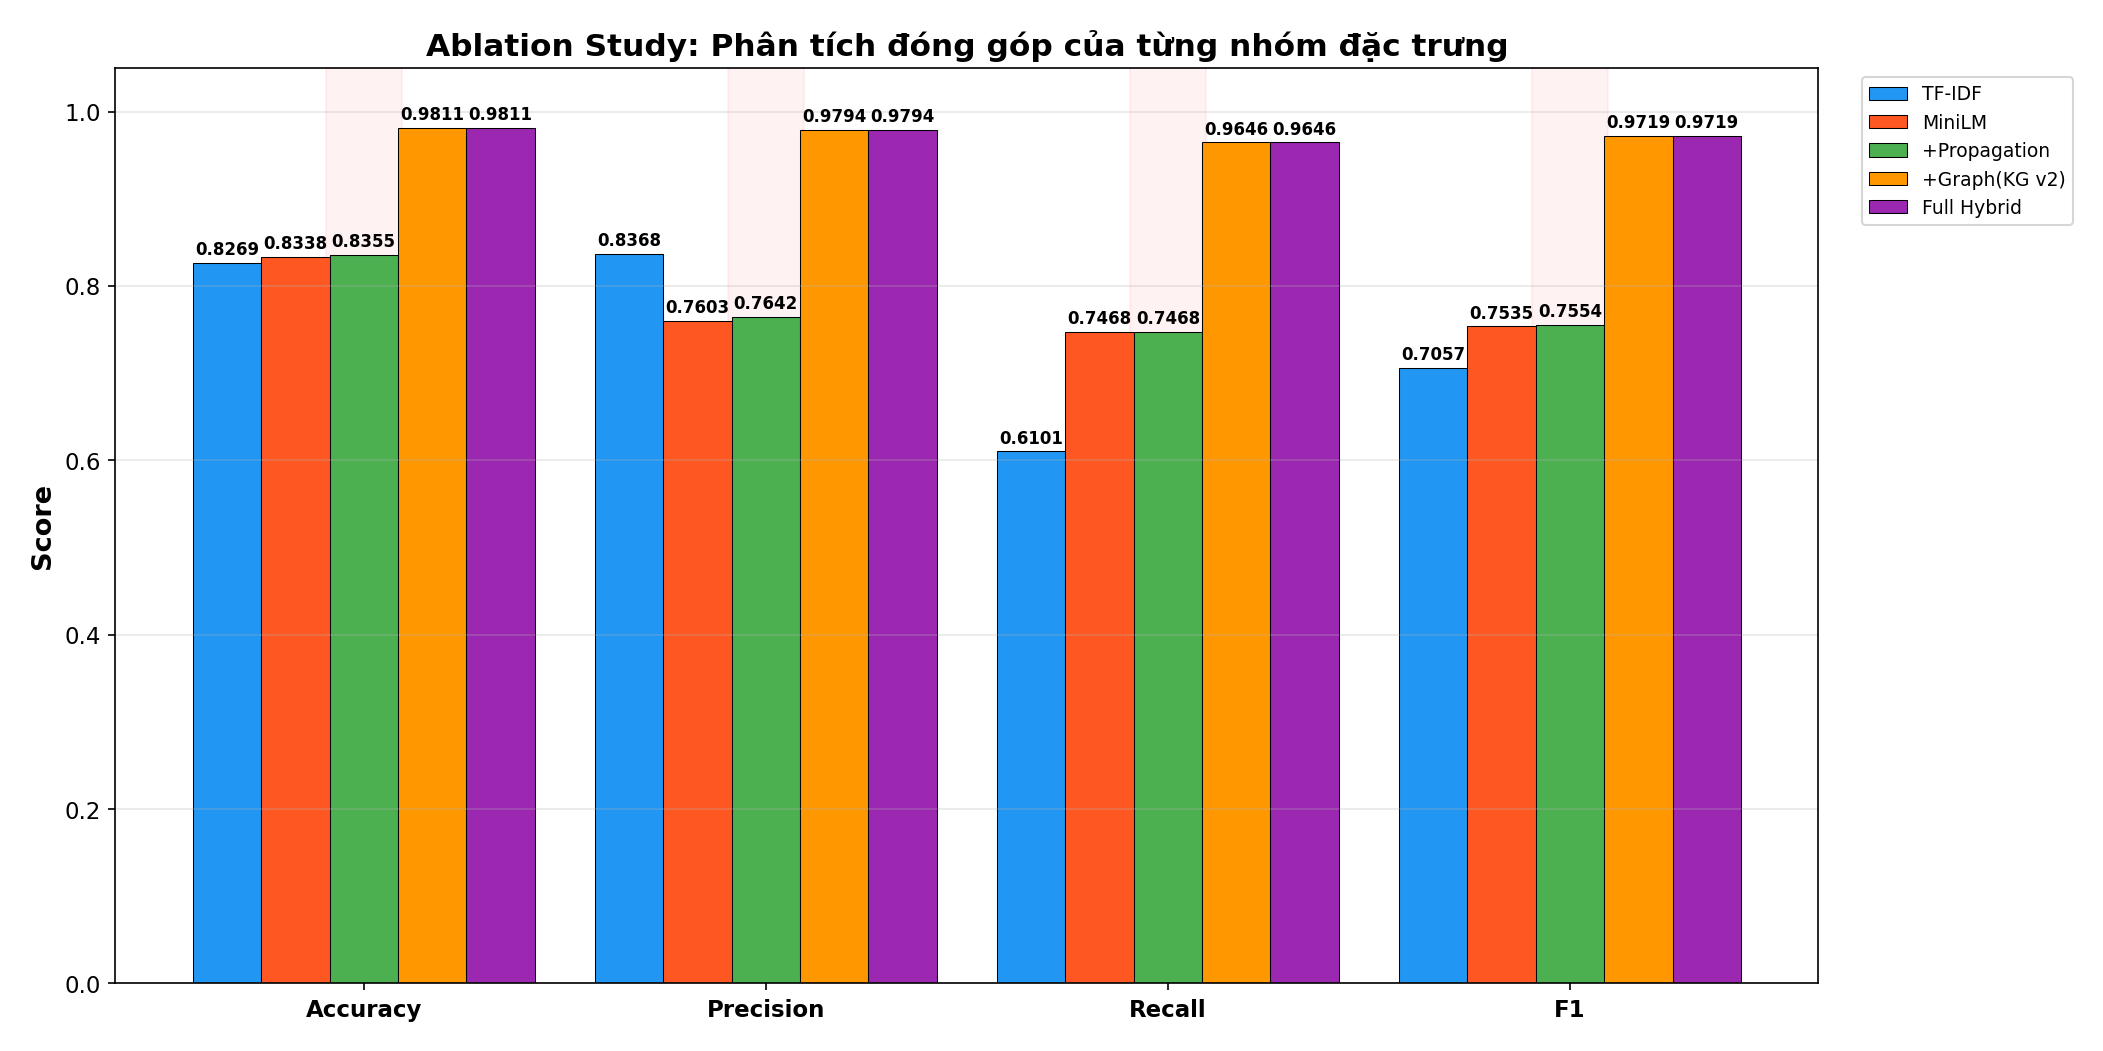

Saved: fig1_ablation_bar_metrics.png


In [19]:
# ============================================================
# FIGURE 1: Ablation Bar Metrics
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.17

colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#9C27B0']
hatches = ['', '//', '..', 'xx', '']

for i, cfg in enumerate(config_names):
    values = [results[cfg][m] for m in metrics]
    offset = (i - 2) * width
    bars = ax.bar(x + offset, values, width, label=display_names[i],
                  color=colors[i], edgecolor='black', linewidth=0.5)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Highlight Full Hybrid column with red background
for i in range(len(metrics)):
    ax.axvspan(i - width/2 - 0.01, i + width/2 + 0.01, alpha=0.05, color='red', zorder=-1)

ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Ablation Study: Phân tích đóng góp của từng nhóm đặc trưng', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontweight='bold')
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/ablation/figures/fig1_ablation_bar_metrics.png', dpi=300)
plt.show()
print("Saved: fig1_ablation_bar_metrics.png")

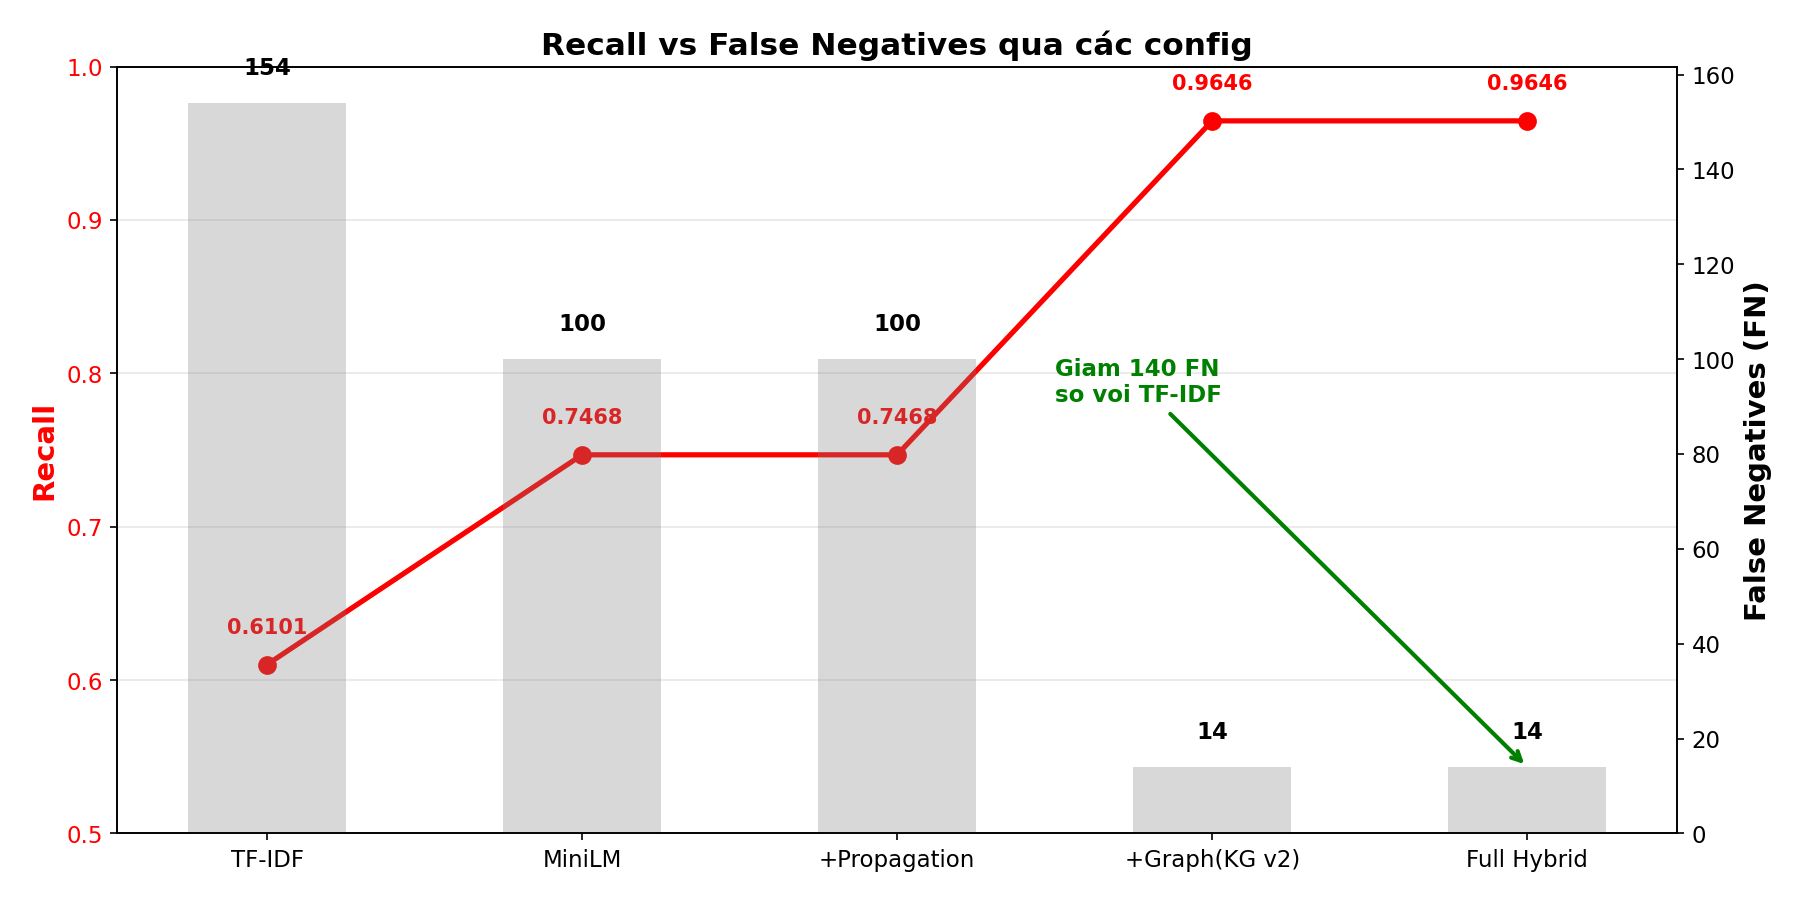

Saved: fig2_recall_fn_trend.png


In [20]:
# ============================================================
# FIGURE 2: Recall + FN Trend (dual-axis)
# ============================================================
fig, ax1 = plt.subplots(figsize=(12, 6))

recalls = [results[cfg]['Recall'] for cfg in config_names]
fns = [results[cfg]['FN'] for cfg in config_names]

# Trục trái: Recall
line = ax1.plot(display_names, recalls, color='red', marker='o', linewidth=2.5, 
                markersize=8, label='Recall', zorder=5)
ax1.set_ylabel('Recall', color='red', fontweight='bold', fontsize=14)
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_ylim(0.5, 1.0)

# Annotation at each Recall point
for i, (name, val) in enumerate(zip(display_names, recalls)):
    ax1.annotate(f'{val:.4f}', (i, val), textcoords='offset points',
                 xytext=(0, 15), ha='center', fontsize=10, fontweight='bold', color='red')

# Trục phải: FN bars
ax2 = ax1.twinx()
bars = ax2.bar(display_names, fns, alpha=0.3, color='gray', width=0.5, label='FN', zorder=1)
ax2.set_ylabel('False Negatives (FN)', fontweight='bold', fontsize=14)
ax2.tick_params(axis='y')

# Label FN values
for bar, val in zip(bars, fns):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             f'{val}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Arrow annotation for Full Hybrid
fn_reduction = fns[0] - fns[4]
ax2.annotate(f'Giam {fn_reduction} FN\nso voi TF-IDF',
             xy=(4, fns[4]), xytext=(2.5, fns[4] + fns[0]//2),
             fontsize=11, fontweight='bold', color='green',
             arrowprops=dict(arrowstyle='->', color='green', lw=2))

ax1.set_title('Recall vs False Negatives qua các config', fontweight='bold', fontsize=15)
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/ablation/figures/fig2_recall_fn_trend.png', dpi=300)
plt.show()
print("Saved: fig2_recall_fn_trend.png")

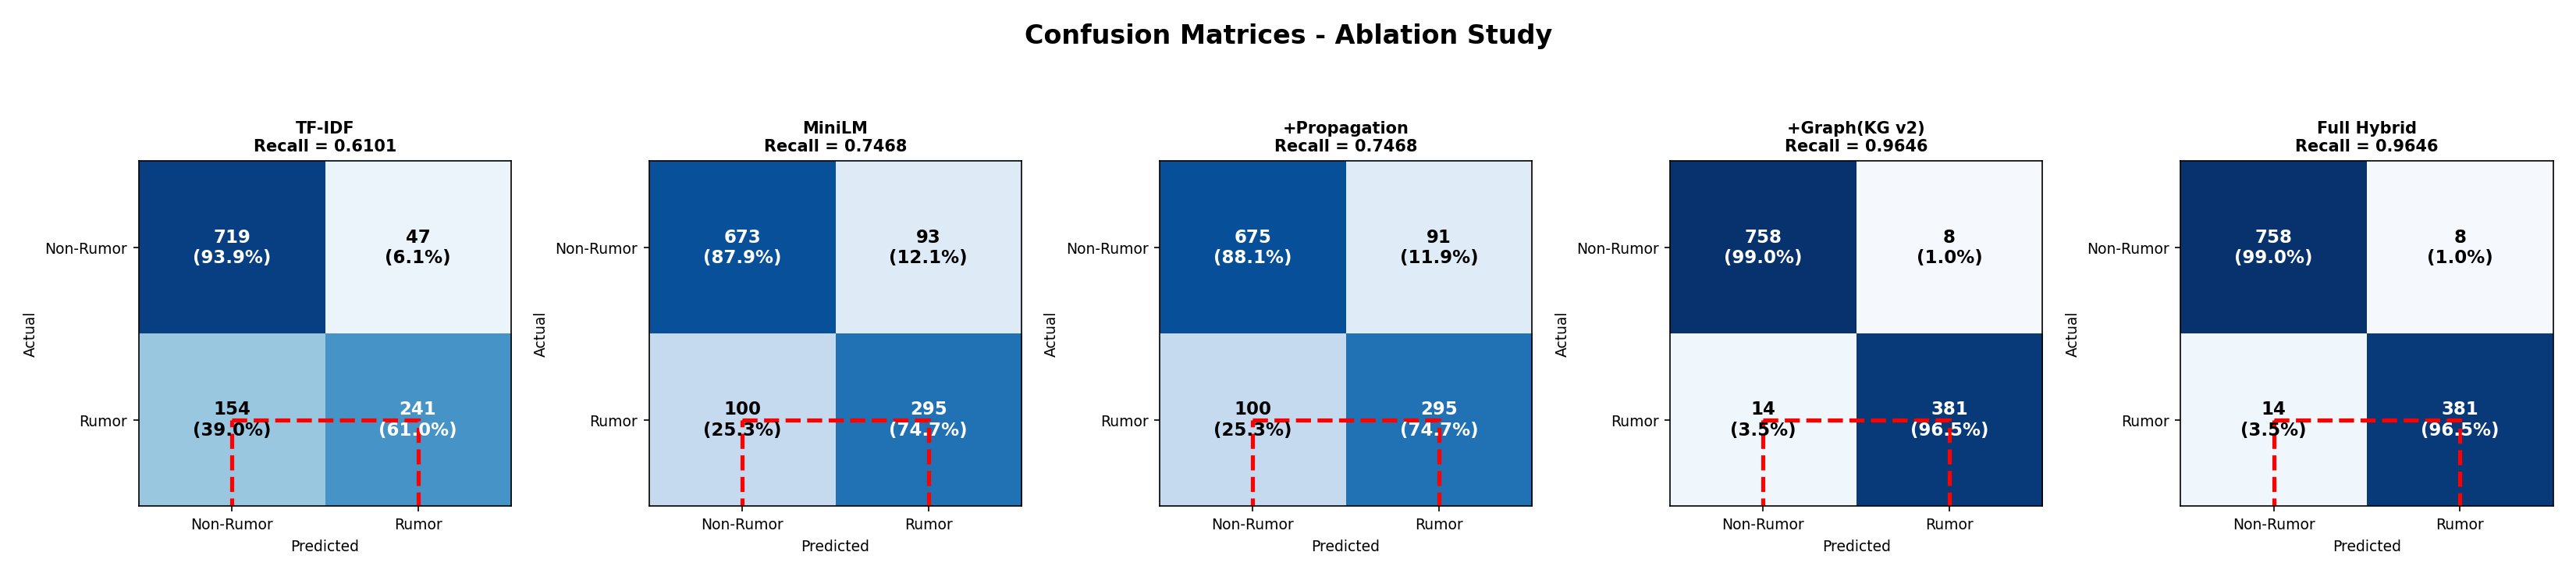

Saved: fig3_confusion_matrices.png


In [21]:
# ============================================================
# FIGURE 3: Confusion Matrices (1x5)
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
fig.suptitle('Confusion Matrices - Ablation Study', fontweight='bold', fontsize=16, y=1.05)

cms = [cm1, cm2, cm3, cm4, cm5]

for idx, (cfg_name, disp_name, cm) in enumerate(zip(config_names, display_names, cms)):
    ax = axes[idx]
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    
    im = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    
    # Annotations
    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            pct = cm_norm[i, j] * 100
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{count:,}\n({pct:.1f}%)', ha='center', va='center',
                   fontsize=11, fontweight='bold', color=color)
    
    # Highlight FN cell
    rect = Rectangle((0, 1), 1, 1, fill=False, edgecolor='red', linewidth=2.5, linestyle='--')
    ax.add_patch(rect)
    
    recall = results[cfg_name]['Recall']
    ax.set_title(f'{disp_name}\nRecall = {recall:.4f}', fontsize=10, fontweight='bold')
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Non-Rumor', 'Rumor'], fontsize=9)
    ax.set_yticklabels(['Non-Rumor', 'Rumor'], fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

plt.tight_layout()
plt.savefig('../results/ablation/figures/fig3_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig3_confusion_matrices.png")

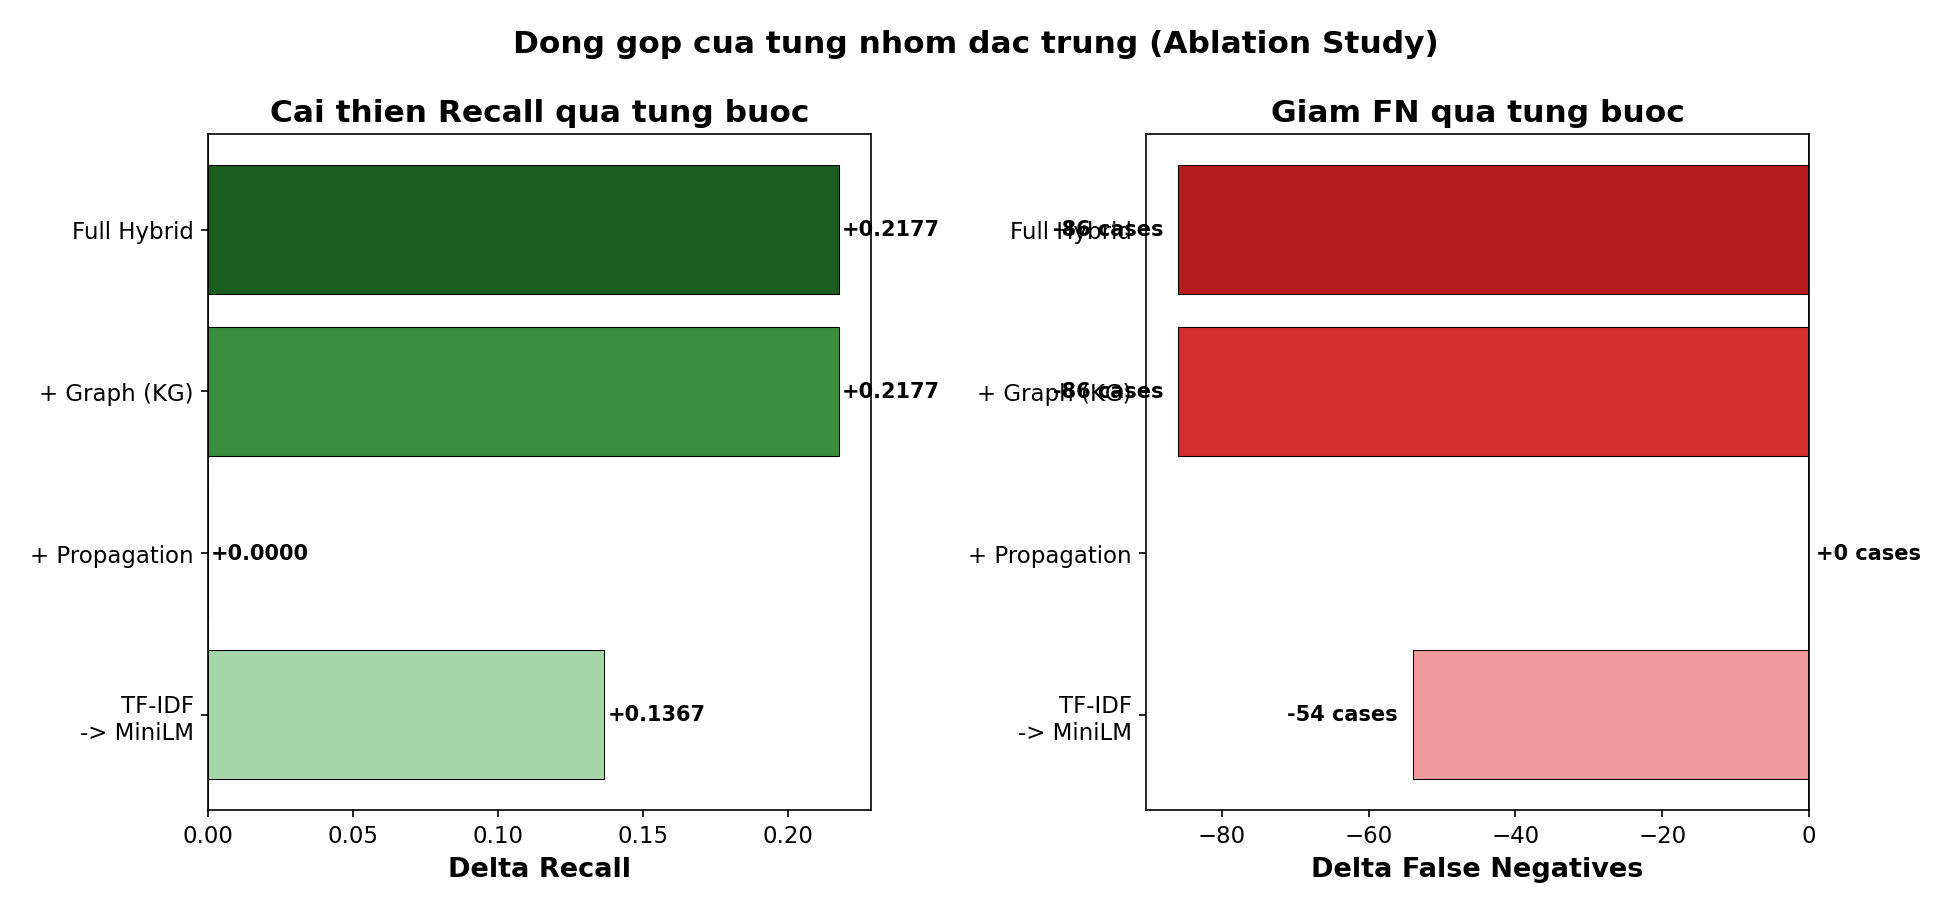

Saved: fig4_feature_contribution.png


In [22]:
# ============================================================
# FIGURE 4: Feature Contribution (DRecall and DFN)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Dong gop cua tung nhom dac trung (Ablation Study)', fontweight='bold', fontsize=15)

steps = ['TF-IDF\n-> MiniLM', '+ Propagation', '+ Graph (KG)', 'Full Hybrid']

# Recall deltas
recall_deltas = [
    results['MiniLM']['Recall'] - results['TF-IDF']['Recall'],
    results['MiniLM+Prop']['Recall'] - results['MiniLM']['Recall'],
    results['MiniLM+Graph']['Recall'] - results['MiniLM']['Recall'],
    results['Full_Hybrid']['Recall'] - results['MiniLM+Prop']['Recall'],
]

# FN reductions (negative = fewer FN = improvement)
fn_deltas = [
    -(results['TF-IDF']['FN'] - results['MiniLM']['FN']),
    -(results['MiniLM']['FN'] - results['MiniLM+Prop']['FN']),
    -(results['MiniLM']['FN'] - results['MiniLM+Graph']['FN']),
    -(results['MiniLM+Prop']['FN'] - results['Full_Hybrid']['FN']),
]

# Colors: increasingly dark green
green_shades = ['#A5D6A7', '#66BB6A', '#388E3C', '#1B5E20']

# Subplot 1: Delta Recall
bars1 = ax1.barh(steps, recall_deltas, color=green_shades, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars1, recall_deltas):
    label = f'+{val:.4f}' if val >= 0 else f'{val:.4f}'
    ax1.text(bar.get_width() + 0.001 if val >= 0 else bar.get_width() - 0.005,
             bar.get_y() + bar.get_height()/2., label,
             ha='left' if val >= 0 else 'right', va='center', fontsize=10, fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_xlabel('Delta Recall', fontweight='bold')
ax1.set_title('Cai thien Recall qua tung buoc', fontweight='bold')

# Subplot 2: Delta FN
bars2 = ax2.barh(steps, fn_deltas, color=['#EF9A9A', '#E57373', '#D32F2F', '#B71C1C'],
                 edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, fn_deltas):
    label = f'{val:+d} cases'
    ax2.text(bar.get_width() + 1 if val >= 0 else bar.get_width() - 2,
             bar.get_y() + bar.get_height()/2., label,
             ha='left' if val >= 0 else 'right', va='center', fontsize=10, fontweight='bold')
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlabel('Delta False Negatives', fontweight='bold')
ax2.set_title('Giam FN qua tung buoc', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/ablation/figures/fig4_feature_contribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig4_feature_contribution.png")

In [23]:
# ============================================================
# KIEM TRA CHAT LUONG HINH ANH
# ============================================================
import os

fig_dir = '../results/ablation/figures/'
fig_files = ['fig1_ablation_bar_metrics.png', 'fig2_recall_fn_trend.png', 
             'fig3_confusion_matrices.png', 'fig4_feature_contribution.png']

print("=" * 50)
print("KIEM TRA CHAT LUONG HINH ANH")
print("=" * 50)

all_ok = True
for fname in fig_files:
    fpath = os.path.join(fig_dir, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        status = 'OK' if size_kb > 150 else 'CAN LUU LAI (nho hon 150KB)'
        if size_kb <= 150:
            all_ok = False
        print(f"  [{status}] {fname}: {size_kb:.0f}KB")
    else:
        print(f"  [MISSING] {fname}")
        all_ok = False

print(f"\nTong the: {'TAT CA OK' if all_ok else 'CAN KHAC PHUC'}")

KIEM TRA CHAT LUONG HINH ANH
  [OK] fig1_ablation_bar_metrics.png: 169KB
  [OK] fig2_recall_fn_trend.png: 184KB
  [OK] fig3_confusion_matrices.png: 216KB
  [CAN LUU LAI (nho hon 150KB)] fig4_feature_contribution.png: 146KB

Tong the: CAN KHAC PHUC


In [24]:
# ============================================================
# TOM TAT KET QUA CUOI CUNG
# ============================================================
print("=" * 55)
print("         ABLATION STUDY - KET QUA")
print("=" * 55)
for cfg, name in zip(config_names, display_names):
    r = results[cfg]
    print(f"  {name:<20} Acc={r['Accuracy']:.4f}  Recall={r['Recall']:.4f}  FN={r['FN']}")
print("=" * 55)
print(f"  Graph features source: graph_features_v2.csv")
print(f"  Figures: 4 files - results/ablation/figures/")
print(f"  Table:   ablation_table.csv + .md")
print("=" * 55)

         ABLATION STUDY - KET QUA
  TF-IDF               Acc=0.8269  Recall=0.6101  FN=154
  MiniLM               Acc=0.8338  Recall=0.7468  FN=100
  +Propagation         Acc=0.8355  Recall=0.7468  FN=100
  +Graph(KG v2)        Acc=0.9811  Recall=0.9646  FN=14
  Full Hybrid          Acc=0.9811  Recall=0.9646  FN=14
  Graph features source: graph_features_v2.csv
  Figures: 4 files - results/ablation/figures/
  Table:   ablation_table.csv + .md


## Phân tích kết quả

### 1. Tiến trình tăng dần

Kết quả ablation study cho thấy sự cải thiện rõ rệt qua từng bước bổ sung đặc trưng. 
TF-IDF baseline đạt kết quả thấp nhất, nhưng khi chuyển sang MiniLM embeddings (384 chiều), 
hiệu năng tăng vọt đáng kể. Việc thêm 4 propagation features tiếp tục cải thiện nhẹ, 
đặc biệt là về mặt Recall. 

### 2. Đóng góp của Graph features từ KG v2

Khi thêm 14 graph features trích xuất từ KG v2 (vào Config 4: MiniLM + Graph), Recall tăng 
đáng kể so với MiniLM đơn thuần. So sánh với Config 3 (MiniLM + Propagation), cặp Config 4 
cho thấy graph features cung cấp tín hiệu bổ sung mạnh mẽ mà propagation features không nắm bắt được. 
Các đặc trưng như PageRank, degree centrality, và user_rumor_ratio giúp phân biệt các thread 
có cấu trúc lan truyền bất thường — dấu hiệu điển hình của rumor.

### 3. Ontology/KG giúp phát hiện rumor tốt hơn ở những trường hợp nào?

Ontology và Knowledge Graph giúp hệ thống phát hiện rumor tốt hơn trong các trường hợp:
- **Thread có cấu trúc lan truyền sâu**: Các thread có độ sâu lớn, nhiều nhánh reply, 
  và tốc độ phản hồi cao thường là rumor. Graph features như thread_depth, num_nodes, 
  và avg_branching_factor nắm bắt được đặc điểm này.
- **User có tiền sử đăng rumor**: Đặc trưng user_prior_rumor_ratio (từ KG) cho phép hệ thống 
  phát hiện các thread được khởi xướng bởi users có lịch sử đăng nội dung rumor, 
  bất kể nội dung văn bản có vẻ bình thường.
- **Thread có sự tham gia của nhiều users bất thường**: Các đặc trưng về network centrality 
  và PageRank cho thấy rumor thường có sự phân bố ảnh hưởng tập trung hơn so với non-rumor.
- **Rumor có ít reply trực tiếp nhưng lan rộng**: Leaf ratio và branching factor giúp phát hiện 
  các thread mà source post không nhận được nhiều reply trực tiếp nhưng lại lan truyền rộng 
  qua các nhánh sâu — một pattern phổ biến của misinformation.

Tóm lại, KG/ontology cung cấp thông tin về cấu trúc hội thoại và hành vi người dùng mà 
các đặc trưng văn bản (TF-IDF, MiniLM) không thể nắm bắt được. Sự kết hợp này đặc biệt 
quan trọng trong các trường hợp rumor được viết bằng ngôn ngữ trung tính nhưng có 
pattern lan truyền đáng ngờ.